Tiempo critico: 90514 s = 25.14 h
D(950C) = 1.725e-11 m2/s


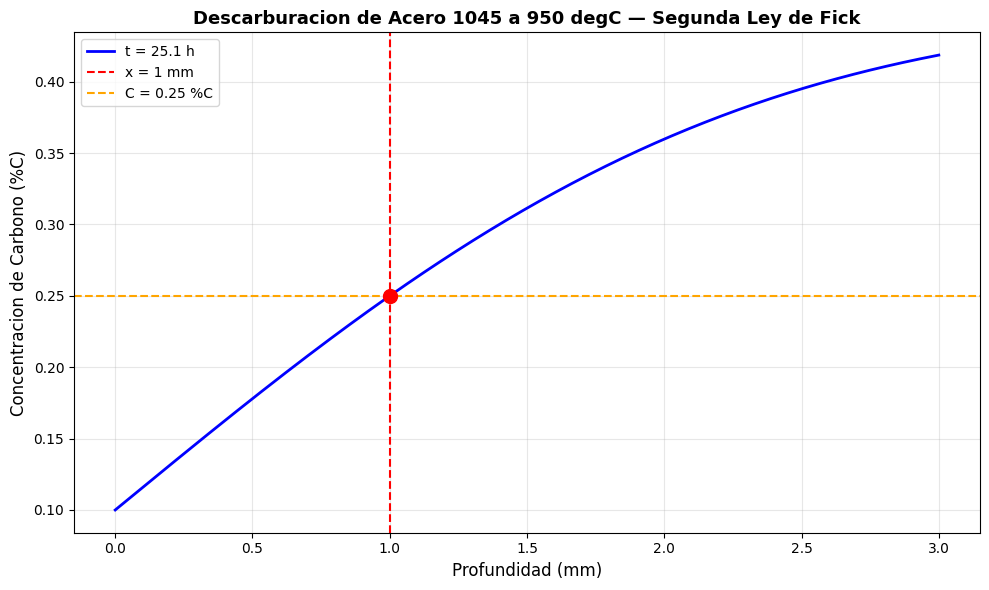

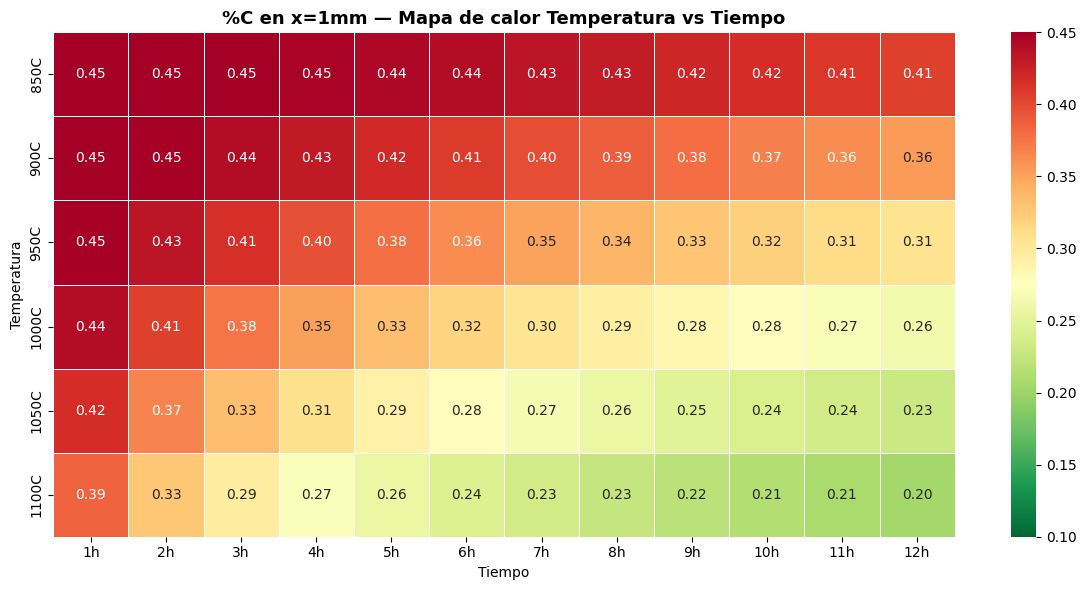

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import erf
from scipy.optimize import brentq

# ── PARAMETROS FISICOS ────────────────────────────
D0 = 2.0e-5      # m2/s — factor pre-exponencial (C en austenita)
Q  = 142_000     # J/mol — energia de activacion
R  = 8.314       # J/(mol*K)

# ── PARAMETROS DEL PROCESO ────────────────────────
C0   = 0.45      # %C inicial — acero SAE 1045
Cs   = 0.10      # %C superficial (atmosfera descarburante)
x_obj = 1e-3     # profundidad objetivo: 1 mm = 0.001 m
C_obj = 0.25     # concentracion objetivo a x_obj
T_C  = 950       # temperatura en Celsius
T_K  = T_C + 273.15
def D(T_C):
    return D0 * np.exp(-Q / (R * (T_C + 273.15)))

def C(x, t, T_C):
    d = D(T_C)
    return Cs + (C0 - Cs) * erf(x / (2 * np.sqrt(d * t)))

# Despejamos: C(x_obj, t) = C_obj  =>  f(t) = 0
f = lambda t: C(x_obj, t, T_C) - C_obj
t_crit = brentq(f, 1, 1e7)
print(f'Tiempo critico: {t_crit:.0f} s = {t_crit/3600:.2f} h')
print(f'D({T_C}C) = {D(T_C):.3e} m2/s')

x = np.linspace(0, 3e-3, 300)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x * 1e3, C(x, t_crit, T_C), 'b-', lw=2, label=f't = {t_crit/3600:.1f} h')
ax.axvline(1.0, color='red', ls='--', label='x = 1 mm')
ax.axhline(0.25, color='orange', ls='--', label='C = 0.25 %C')
ax.scatter([1.0], [0.25], s=100, color='red', zorder=5)
ax.set_xlabel('Profundidad (mm)', fontsize=12)
ax.set_ylabel('Concentracion de Carbono (%C)', fontsize=12)
ax.set_title('Descarburacion de Acero 1045 a 950 degC — Segunda Ley de Fick', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('perfil_descarburacion.png', dpi=150)
plt.show()
temps = np.arange(850, 1101, 50)      # 850 a 1050 degC
times = np.arange(1, 13) * 3600       # 1 a 12 horas
grid  = np.array([[C(x_obj, t, T) for t in times] for T in temps])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(grid, annot=True, fmt='.2f',
            xticklabels=[f'{int(t/3600)}h' for t in times],
            yticklabels=[f'{int(T)}C' for T in temps],
            cmap='RdYlGn_r', ax=ax, linewidths=0.5,
            vmin=0.10, vmax=0.45)
ax.set_title('%C en x=1mm — Mapa de calor Temperatura vs Tiempo', fontsize=13, fontweight='bold')
ax.set_xlabel('Tiempo'); ax.set_ylabel('Temperatura')
plt.tight_layout()
plt.savefig('mapa_calor_descarburacion.png', dpi=150)
plt.show()
